# NV Diamond Pulse Data Analysis

This notebook analyzes new measurement data from `.npy` files in the `Avg_npy_pulse` folder. Each file corresponds to one crystallographic direction in an NV- 100 faced diamond. The notebook will:
- Examine the data structure and determine the number of pixels
- Visualize time traces for each pixel and direction
- Reconstruct the 2D pixel grid (zig-zag order)
- Visualize the spatial distribution at selected time points

**Data structure:**
- Each `.npy` file: 2D array, first column is time (seconds), remaining columns are pixel voltages (units: volts or as specified)
- Four files: one per crystallographic direction

# 1. find slopes



In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv("results.csv")

axes_order = ["d1", "d2", "d3", "d4"]

f_left_centers_mhz = np.array([
    float(results_df.loc[results_df["name"] == "d1_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d2_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d3_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d4_f_left_meas_MHz", "value"].iloc[0]),
], dtype=float)

odmr_csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"

odmr_df = pd.read_csv(odmr_csv_path, sep=r"\s+")
odmr_df.columns = [c.strip() for c in odmr_df.columns]

freq_col = [c for c in odmr_df.columns if "freq" in c.lower()][0]
sig_col = [c for c in odmr_df.columns if c != freq_col][0]

f_hz_odmr = odmr_df[freq_col].to_numpy(dtype=float)
y_raw_odmr = odmr_df[sig_col].to_numpy(dtype=float)

idx = np.argsort(f_hz_odmr)
f_hz_odmr = f_hz_odmr[idx]
y_raw_odmr = y_raw_odmr[idx]

f_mhz_odmr = f_hz_odmr / 1e6
f_ghz_odmr = f_hz_odmr / 1e9

n_top = max(10, len(y_raw_odmr) // 20)
baseline_odmr = np.mean(np.sort(y_raw_odmr)[-n_top:])
S_odmr = y_raw_odmr / baseline_odmr

print("Tracked lower-transition centers [MHz]:", f_left_centers_mhz)

Tracked lower-transition centers [MHz]: [2791.20577148 2803.93502334 2855.26217136 2866.88305566]


##convert to fractional isgnal#


In [110]:

manual_windows = {
    "d1": (2788.0, 2788.9),
    "d2": (2801.0, 2801.7),
    "d3": (2852.0, 2853.0),
    "d4": (2864.0, 2865.0),
}

manual_windows

{'d1': (2788.0, 2788.9),
 'd2': (2801.0, 2801.7),
 'd3': (2852.0, 2853.0),
 'd4': (2864.0, 2865.0)}

In [111]:
slope_rows = []

for ax in axes_order:
    f_min, f_max = manual_windows[ax]
    center = f_left_centers_mhz[axes_order.index(ax)]

    mask = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask]
    y_fit = S_odmr[mask]

    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    slope = coeffs[0]
    intercept = coeffs[1]

    y_line = slope * x_fit + intercept

    slope_rows.append({
        "axis": ax,
        "center_MHz": center,
        "fit_start_MHz": f_min,
        "fit_end_MHz": f_max,
        "slope_fraction_per_MHz": slope,
        "intercept": intercept,
        "n_points": np.sum(mask)
    })

slopes_df = pd.DataFrame(slope_rows)
display(slopes_df)

,axis,center_MHz,fit_start_MHz,fit_end_MHz,slope_fraction_per_MHz,intercept,n_points
0,d1,2791.205771,2788.0,2788.9,-0.076893,215.358173,5
1,d2,2803.935023,2801.0,2801.7,-0.087911,247.206124,4
2,d3,2855.262171,2852.0,2853.0,-0.034051,98.094483,6
3,d4,2866.883056,2864.0,2865.0,-0.022902,66.562423,6


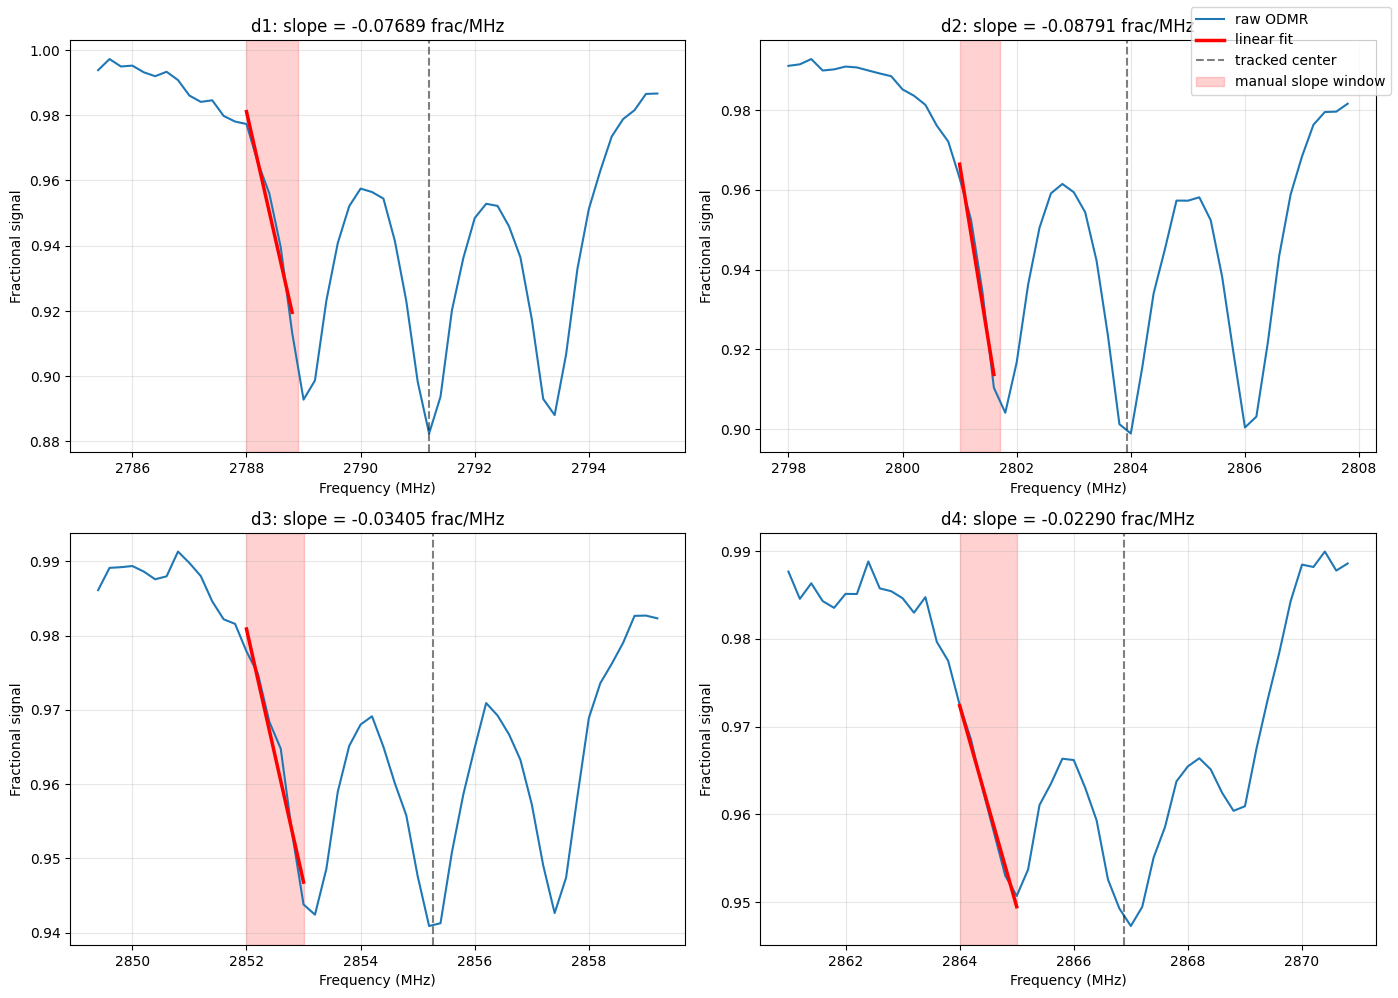

Final manually selected slopes [fractional signal per MHz]:
d1: -0.076893
d2: -0.087911
d3: -0.034051
d4: -0.022902


In [112]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# Wider view around each tracked lower transition
left_span_mhz = 6.0
right_span_mhz = 4.0

for i, ax_name in enumerate(axes_order):
    center = slopes_df.loc[i, "center_MHz"]
    f_min = slopes_df.loc[i, "fit_start_MHz"]
    f_max = slopes_df.loc[i, "fit_end_MHz"]
    slope = slopes_df.loc[i, "slope_fraction_per_MHz"]
    intercept = slopes_df.loc[i, "intercept"]

    mask_zoom = (f_mhz_odmr >= center - left_span_mhz) & (f_mhz_odmr <= center + right_span_mhz)
    mask_fit = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask_fit]
    y_line = slope * x_fit + intercept

    axes[i].plot(f_mhz_odmr[mask_zoom], S_odmr[mask_zoom], lw=1.5, label="raw ODMR")
    axes[i].plot(x_fit, y_line, color="red", lw=2.5, label="linear fit")
    axes[i].axvline(center, color="k", ls="--", alpha=0.5, label="tracked center" if i == 0 else None)
    axes[i].axvspan(f_min, f_max, color="red", alpha=0.18, label="manual slope window" if i == 0 else None)

    axes[i].set_title(f"{ax_name}: slope = {slope:.5f} frac/MHz")
    axes[i].set_xlabel("Frequency (MHz)")
    axes[i].set_ylabel("Fractional signal")
    axes[i].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

slopes_fraction_per_MHz = slopes_df["slope_fraction_per_MHz"].to_numpy(dtype=float)

print("Final manually selected slopes [fractional signal per MHz]:")
for i, ax in enumerate(axes_order):
    print(f"{ax}: {slopes_fraction_per_MHz[i]: .6f}")

## 2.  Pulse data analysis and phase selection

In [113]:
import os
import glob
import matplotlib.pyplot as plt

folder = 'Avg_npy_pulse'

npy_files = sorted(glob.glob(os.path.join(folder, "Pulse_avg_d*.npy")))
print("Found files:", npy_files)

all_data = []
for f in npy_files:
    arr = np.load(f)
    print(f"File: {os.path.basename(f)} | Shape: {arr.shape}")
    print("First 3 rows:\n", arr[:3])
    all_data.append(arr)
    print("---")

Found files: ['Avg_npy_pulse/Pulse_avg_d1.npy', 'Avg_npy_pulse/Pulse_avg_d2.npy', 'Avg_npy_pulse/Pulse_avg_d3.npy', 'Avg_npy_pulse/Pulse_avg_d4.npy']
File: Pulse_avg_d1.npy | Shape: (457, 962)
First 3 rows:
 [[ 0.00000000e+00  7.94575342e+01  9.79260173e+01 ...  5.02662066e+01
   1.83949340e+02  2.60874027e+02]
 [ 3.86400000e-04  6.97000215e+01  7.90484173e+01 ...  5.74127265e+01
   1.92701682e+02  2.00465708e+02]
 [ 7.72800000e-04  6.78735524e+01  1.19341061e+02 ... -2.67764658e+01
   1.81571253e+02  2.52918467e+02]]
---
File: Pulse_avg_d2.npy | Shape: (457, 962)
First 3 rows:
 [[0.00000000e+00 1.40353527e+01 4.02364506e+00 ... 6.39354888e+01
  4.24899231e+01 1.02095369e+02]
 [3.86400000e-04 2.03529379e+01 2.75272821e+01 ... 4.39097611e+01
  1.35727491e+02 1.21714107e+02]
 [7.72800000e-04 2.02419408e+01 3.76465182e+01 ... 3.91368855e+01
  1.41268097e+02 1.45217744e+02]]
---
File: Pulse_avg_d3.npy | Shape: (457, 962)
First 3 rows:
 [[ 0.00000000e+00  4.67520757e+00 -3.00801733e+01 ... 

In [ ]:
time = all_data[0][:, 0]

voltage_d1 = all_data[0][:, 1:]
voltage_d2 = all_data[1][:, 1:]
voltage_d3 = all_data[2][:, 1:]
voltage_d4 = all_data[3][:, 1:]

voltage_stack = np.stack([voltage_d1, voltage_d2, voltage_d3, voltage_d4], axis=0)

n_timepoints = voltage_stack.shape[1]
n_pixels = voltage_stack.shape[2]

time shape: (457,)
voltage_d1 shape: (457, 961)
voltage_d2 shape: (457, 961)
voltage_d3 shape: (457, 961)
voltage_d4 shape: (457, 961)
voltage_stack shape: (4, 457, 961)
Channel order: ['d1', 'd2', 'd3', 'd4']
Time step [s]: 0.0003864
Number of pixels: 961
sqrt(n_pixels): 31.0


In [115]:
grid_size = int(np.sqrt(n_pixels))
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size

    if col % 2 == 0:
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx
    else:
        grid[row, grid_size - 1 - col] = idx

print("Grid mapping shape:", grid.shape)
print(grid)

Grid mapping shape: (31, 31)
[[960 899 898 837 836 775 774 713 712 651 650 589 588 527 526 465 464 403
  402 341 340 279 278 217 216 155 154  93  92  31  30]
 [959 900 897 838 835 776 773 714 711 652 649 590 587 528 525 466 463 404
  401 342 339 280 277 218 215 156 153  94  91  32  29]
 [958 901 896 839 834 777 772 715 710 653 648 591 586 529 524 467 462 405
  400 343 338 281 276 219 214 157 152  95  90  33  28]
 [957 902 895 840 833 778 771 716 709 654 647 592 585 530 523 468 461 406
  399 344 337 282 275 220 213 158 151  96  89  34  27]
 [956 903 894 841 832 779 770 717 708 655 646 593 584 531 522 469 460 407
  398 345 336 283 274 221 212 159 150  97  88  35  26]
 [955 904 893 842 831 780 769 718 707 656 645 594 583 532 521 470 459 408
  397 346 335 284 273 222 211 160 149  98  87  36  25]
 [954 905 892 843 830 781 768 719 706 657 644 595 582 533 520 471 458 409
  396 347 334 285 272 223 210 161 148  99  86  37  24]
 [953 906 891 844 829 782 767 720 705 658 643 596 581 534 519 472 45

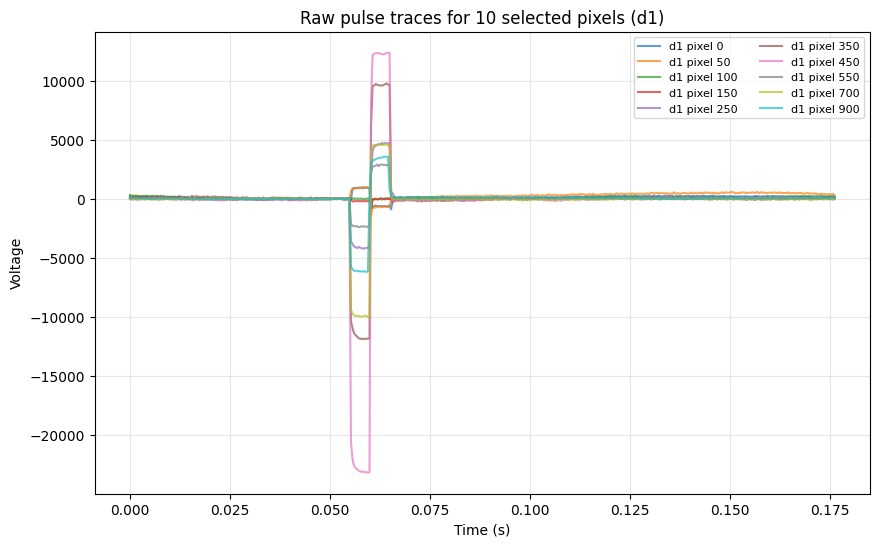

In [125]:
pixel_list = [0, 50, 100, 150, 250, 350, 450, 550, 700, 900]

plt.figure(figsize=(10, 6))
for pixel_idx in pixel_list:
    plt.plot(time, voltage_d1[:, pixel_idx], alpha=0.7, label=f'd1 pixel {pixel_idx}')

plt.xlabel("Time (s)")
plt.ylabel("Voltage")
plt.title("Raw pulse traces for 10 selected pixels (d1)")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
baseline_n = 20

baseline_voltage = np.mean(voltage_stack[:, :baseline_n, :], axis=1, keepdims=True)

fractional_signal = voltage_stack / baseline_voltage
delta_fractional_signal = fractional_signal - 1.0

baseline_voltage shape: (4, 1, 961)
fractional_signal shape: (4, 457, 961)
delta_fractional_signal shape: (4, 457, 961)


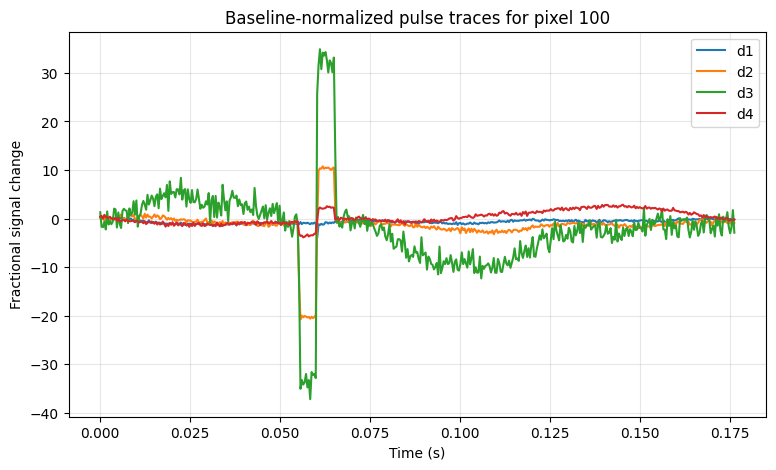

In [118]:
pixel_idx = 100

plt.figure(figsize=(9, 5))
plt.plot(time, delta_fractional_signal[0, :, pixel_idx], label="d1")
plt.plot(time, delta_fractional_signal[1, :, pixel_idx], label="d2")
plt.plot(time, delta_fractional_signal[2, :, pixel_idx], label="d3")
plt.plot(time, delta_fractional_signal[3, :, pixel_idx], label="d4")

plt.xlabel("Time (s)")
plt.ylabel("Fractional signal change")
plt.title(f"Baseline-normalized pulse traces for pixel {pixel_idx}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
time_index_df = pd.DataFrame({
    "index": np.arange(len(time)),
    "time_s": time
})




# LETS SELECT POSITIVE< NEGATIVE OFF PHASES, One OFF time, one positive-phase time, one negative-phase time


In [ ]:
pos_idx = 150
neg_idx = 161
off_indices = np.array([0, 1, 2, 3, 4, 6, 7 , 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90])

V_off = np.mean(voltage_stack[:, off_indices, :], axis=1)   # shape (4, 961)
V_pos = voltage_stack[:, pos_idx, :]                        # shape (4, 961)
V_neg = voltage_stack[:, neg_idx, :]                        # shape (4, 961)

print("V_off shape:", V_off.shape)
print("V_pos shape:", V_pos.shape)
print("V_neg shape:", V_neg.shape)

V_off shape: (4, 961)
V_pos shape: (4, 961)
V_neg shape: (4, 961)


In [120]:
slopes_abs = np.abs(slopes_fraction_per_MHz)

deltaS_pos = (V_pos - V_off) / V_off
deltaS_neg = (V_neg - V_off) / V_off

deltaNu_pos = deltaS_pos / slopes_abs[:, None]   # MHz
deltaNu_neg = deltaS_neg / slopes_abs[:, None]   # MHz

print("deltaNu_pos shape:", deltaNu_pos.shape)
print("deltaNu_neg shape:", deltaNu_neg.shape)

deltaNu_pos shape: (4, 961)
deltaNu_neg shape: (4, 961)


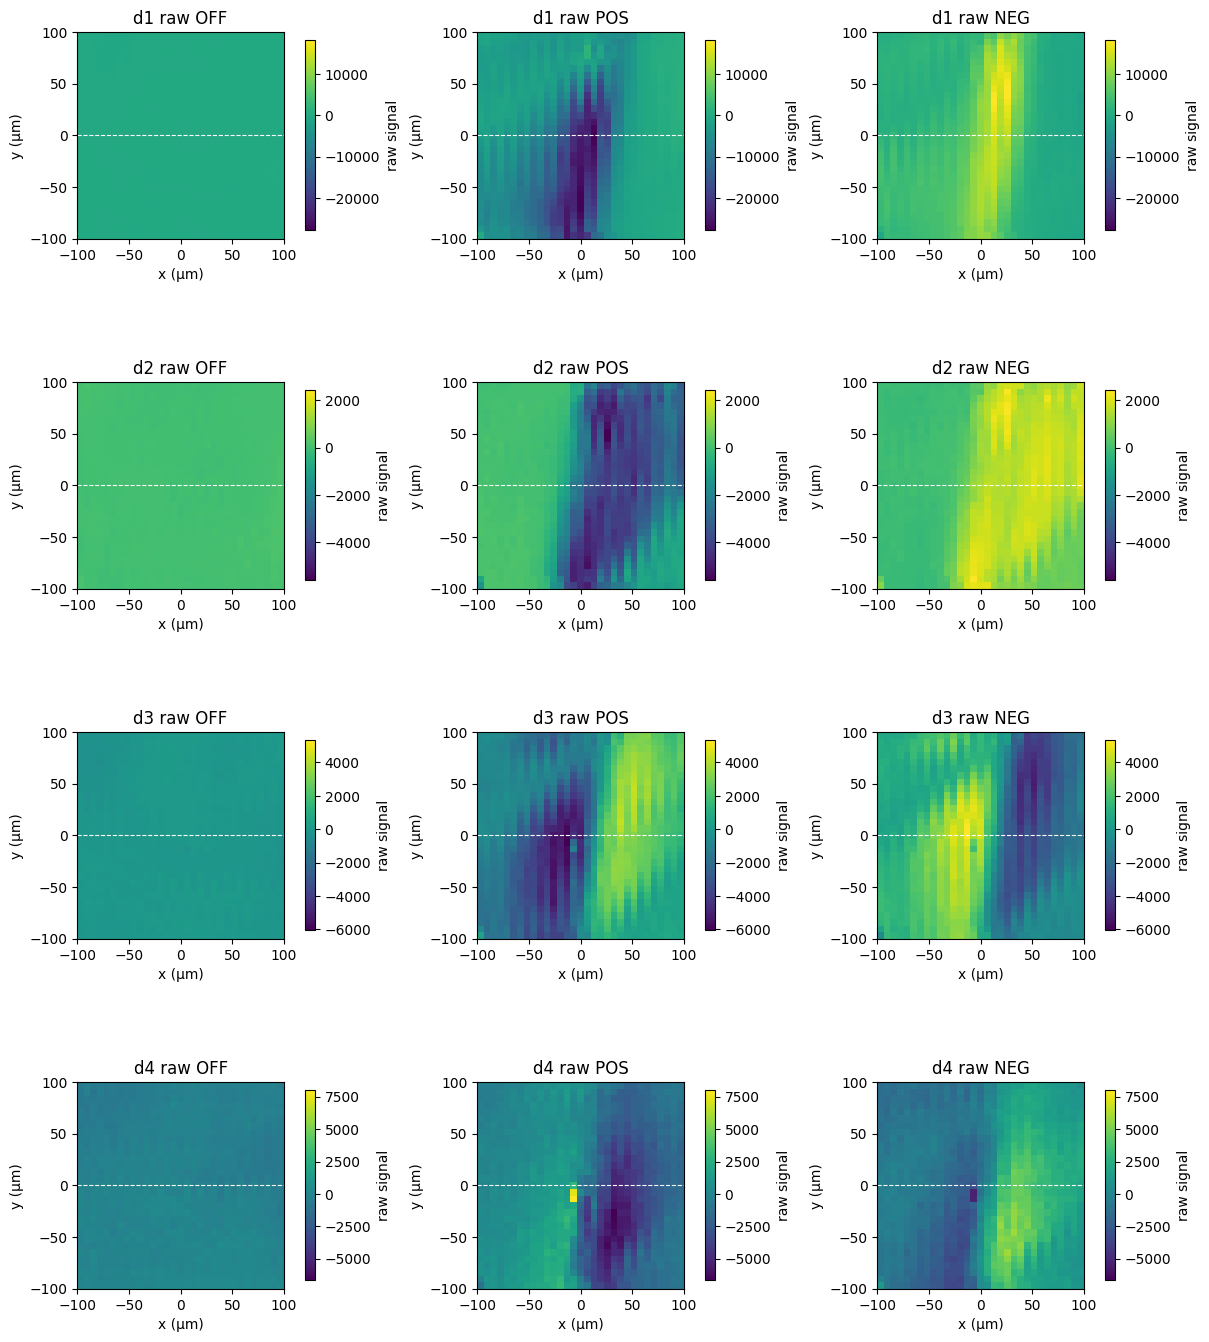

In [121]:
extent_um = [-100, 100, -100, 100]

Voff_maps = V_off[:, grid]
Vpos_maps = V_pos[:, grid]
Vneg_maps = V_neg[:, grid]

fig, axes = plt.subplots(4, 3, figsize=(12, 14), constrained_layout=True)

for i, ax_name in enumerate(axes_order):
    arrs = [Voff_maps[i], Vpos_maps[i], Vneg_maps[i]]
    titles = [
        f"{ax_name} raw OFF",
        f"{ax_name} raw POS",
        f"{ax_name} raw NEG"
    ]

    # same color scale within one axis for fair comparison
    vmin = min(np.nanmin(a) for a in arrs)
    vmax = max(np.nanmax(a) for a in arrs)

    for j in range(3):
        im = axes[i, j].imshow(
            arrs[j],
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )
        axes[i, j].set_title(titles[j])
        axes[i, j].set_xlabel("x (µm)")
        axes[i, j].set_ylabel("y (µm)")
        axes[i, j].plot([extent_um[0], extent_um[1]], [0, 0], "w--", lw=0.8)

        cbar = plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)
        cbar.set_label("raw signal")

plt.show()

# magnetic fielf reconstruction 

In [122]:
# --- Load A and A+ only ---

import pandas as pd
import numpy as np

A_csv_path = "A_results.csv"
A_results_df = pd.read_csv(A_csv_path)

axes_order = ["d1", "d2", "d3", "d4"]

A = np.zeros((4, 3), dtype=float)
A_plus = np.zeros((3, 4), dtype=float)

for i, ax in enumerate(axes_order):
    for j, comp in enumerate(["Bx", "By", "Bz"]):
        A[i, j] = float(
            A_results_df.loc[
                (A_results_df["group"] == "A_matrix") &
                (A_results_df["row"] == ax) &
                (A_results_df["col"] == comp),
                "value"
            ].iloc[0]
        )

for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, ax in enumerate(axes_order):
        A_plus[i, j] = float(
            A_results_df.loc[
                (A_results_df["group"] == "A_plus") &
                (A_results_df["row"] == comp) &
                (A_results_df["col"] == ax),
                "value"
            ].iloc[0]
        )

print("A shape:", A.shape)
print("A_plus shape:", A_plus.shape)
print("A =\n", A)
print("A_plus =\n", A_plus)

A shape: (4, 3)
A_plus shape: (3, 4)
A =
 [[  0.35698419 -22.16305711 -17.19034537]
 [  0.3556599  -21.88186793  17.5808397 ]
 [-22.81212502   2.47932702 -16.0860763 ]
 [-21.44250072   2.2754757   15.65000906]]
A_plus =
 [[-0.00196802 -0.00292597 -0.02287232 -0.02238438]
 [-0.02295424 -0.02253042 -0.00040755 -0.00032227]
 [-0.01562025  0.01578408 -0.01386735  0.01475487]]


In [123]:
B_pos_mT = A_plus @ deltaNu_pos   # shape (3, 961)
B_neg_mT = A_plus @ deltaNu_neg   # shape (3, 961)

print("B_pos_mT shape:", B_pos_mT.shape)
print("B_neg_mT shape:", B_neg_mT.shape)

# Convert to nT
B_pos_nT = 1e6 * B_pos_mT
B_neg_nT = 1e6 * B_neg_mT

# 4. Reshape to 31x31 maps
# --------------------------------------------------
Bx_pos_map = B_pos_nT[0][grid]
By_pos_map = B_pos_nT[1][grid]
Bz_pos_map = B_pos_nT[2][grid]

Bx_neg_map = B_neg_nT[0][grid]
By_neg_map = B_neg_nT[1][grid]
Bz_neg_map = B_neg_nT[2][grid]

Bmag_pos_map = np.sqrt(Bx_pos_map**2 + By_pos_map**2 + Bz_pos_map**2)
Bmag_neg_map = np.sqrt(Bx_neg_map**2 + By_neg_map**2 + Bz_neg_map**2)

B_pos_mT shape: (3, 961)
B_neg_mT shape: (3, 961)


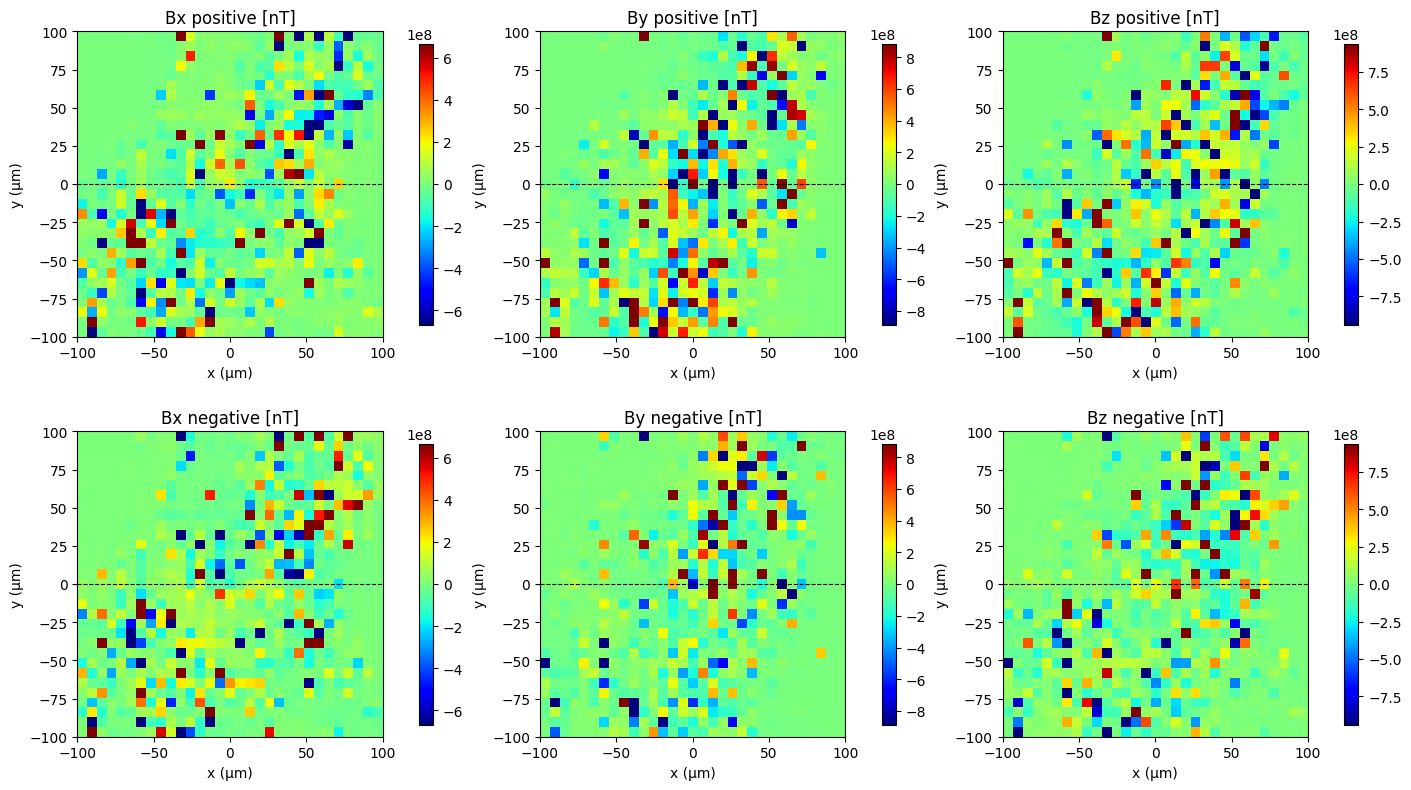

In [124]:
# 6. Plot Bx, By, Bz for ALL FOUR AXES combined
#    (This is the actual reconstructed field vector)
# --------------------------------------------------
extent_um = [-100, 100, -100, 100]

# Use robust symmetric color scale per component, shared between pos/neg
Bx_lim = max(np.nanpercentile(np.abs(Bx_pos_map), 95),
             np.nanpercentile(np.abs(Bx_neg_map), 95))
By_lim = max(np.nanpercentile(np.abs(By_pos_map), 95),
             np.nanpercentile(np.abs(By_neg_map), 95))
Bz_lim = max(np.nanpercentile(np.abs(Bz_pos_map), 95),
             np.nanpercentile(np.abs(Bz_neg_map), 95))

if Bx_lim == 0: Bx_lim = 1.0
if By_lim == 0: By_lim = 1.0
if Bz_lim == 0: Bz_lim = 1.0

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

maps = [
    ("Bx positive [nT]", Bx_pos_map, Bx_lim),
    ("By positive [nT]", By_pos_map, By_lim),
    ("Bz positive [nT]", Bz_pos_map, Bz_lim),
    ("Bx negative [nT]", Bx_neg_map, Bx_lim),
    ("By negative [nT]", By_neg_map, By_lim),
    ("Bz negative [nT]", Bz_neg_map, Bz_lim),
]

for ax, (title, data, lim) in zip(axes.ravel(), maps):
    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    ax.set_title(title)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.plot([extent_um[0], extent_um[1]], [0, 0], "k--", lw=0.8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()